# 02 BEHACOM Basic EDA

Cel: przeprowadzić wstępną eksplorację danych BEHACOM na kolumnach rdzeniowych (bez digrafów, bez per-key keystroke/press_release).

## Założenia metodologiczne

- Analizujemy behawioralną ciągłość pracy, nie stan psychiczny użytkownika.
- Na tym etapie jedynie **dokumentujemy** problemy jakościowe. Czyszczenie nastąpi przy feature engineering.
- User2 jest wykluczony (179 wierszy, czyli zbyt mało danych).
- Digrafy i per-key kolumny są pomijane celowo; ich włączenie nastąpi w osobnym etapie.

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("../data/BEHACOM/Behacom")
ENCODING = "latin-1"
EXCLUDE_USERS = [2]

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Sekcja 1: Selektywne ładowanie danych

In [2]:
def discover_csv_files(data_dir: Path) -> list[Path]:
  """ Discover BEHACOM user CSV files sorted by numeric user id. """

  def sort_key(path: Path) -> int:
    """ Extract the numeric user id from a BEHACOM CSV path. """
    match = re.search(r"User(\d+)", path.parent.name)
    return int(match.group(1)) if match else 10_000

  return sorted(data_dir.glob("User*/User*_BEHACOM.csv"), key=sort_key)


def get_core_columns(sample_path: Path) -> list[str]:
  """ Read header and return core columns (no digraphs, no per-key). """
  header = pd.read_csv(sample_path, encoding=ENCODING, nrows=0).columns.tolist()
  skip_prefixes = ("digraph_", "keystrokes_key_", "press_release_average_")
  keep = []
  for col in header:
    if col == "press_release_average_interval":
      keep.append(col)
      continue
    if any(col.startswith(p) for p in skip_prefixes):
      continue
    keep.append(col)
  return keep


files = discover_csv_files(DATA_DIR)
print(f"Found {len(files)} CSV files")

core_cols = get_core_columns(files[0])
print(f"Core columns to load: {len(core_cols)}")
print(f"Skipped: digraph_*, keystrokes_key_*, press_release_average_* (per-key)")

Found 12 CSV files


Core columns to load: 85
Skipped: digraph_*, keystrokes_key_*, press_release_average_* (per-key)


In [3]:
frames: list[pd.DataFrame] = []
for path in files:
  df_chunk = pd.read_csv(path, encoding=ENCODING, usecols=core_cols, low_memory=False)
  frames.append(df_chunk)
  print(f"  {path.parent.name}: {len(df_chunk):>6,} rows")

df = pd.concat(frames, ignore_index=True)
df["USER"] = df["USER"].astype(int)
df = df[~df["USER"].isin(EXCLUDE_USERS)].copy()

df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.dayofweek
df["date"] = df["datetime"].dt.date

# is_idle: no keystrokes AND no mouse actions
mouse_action_cols = [c for c in df.columns if c.startswith("mouse_action_counter_")]
df["mouse_total"] = df[mouse_action_cols].sum(axis=1)
df["is_idle"] = (df["keystroke_counter"] == 0) & (df["mouse_total"] == 0)

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"\nLoaded: {len(df):,} rows, {df['USER'].nunique()} users, {len(df.columns)} columns")
print(f"Memory: {mem_mb:.1f} MB")

# Sanity checks
assert 2 not in df["USER"].values, "User 2 should be excluded"
assert df["datetime"].notna().all(), "Found NaT in datetime column"
print("\n✓ All sanity checks passed")

  User0:  6,059 rows


  User1: 42,281 rows
  User2:    179 rows


  User3:  3,221 rows


  User4: 10,114 rows


  User5:  2,128 rows


...

  User8:  5,404 rows


  User9:  7,920 rows


  User10: 15,358 rows


  User11: 17,284 rows



Loaded: 166,879 rows, 11 users, 91 columns
Memory: 127.6 MB

✓ All sanity checks passed


Dane wczytano selektywnie: 85 kolumn źródłowych bez digrafów i per-key timingów. Po dodaniu kolumn pomocniczych (`datetime`, `hour`, `weekday`, `date`, `mouse_total`, `is_idle`) notebook pracuje na 91 kolumnach i 166 879 wierszach.

To potwierdza, że podstawowe EDA można wykonać w pamięci bez pełnego schematu 12 051 kolumn. Decyzja na dalsze kroki: digrafy i per-key features pozostają poza podstawową analizą, dopóki nie pojawi się konkretna hipoteza ich użycia.

## Sekcja 2: Profil danych: typy, braki, domeny wartości

Dla każdej kolumny sprawdzamy typ, liczbę jawnych braków (`NaN`), liczbę unikalnych wartości i zakres.

Ważne rozróżnienie metodologiczne:

- **Jawne braki (`NaN`)**: klasyczne missing values.
- **Semantyczne zera / silent nulls**: wartości `0`, które mogą oznaczać brak zdarzenia, brak możliwości obliczenia metryki albo problem pomiarowy. Te wartości warto analizować warunkowo, np. tylko gdy wystąpiło pisanie lub ruch myszy.

Celem tej sekcji jest ustalenie, czy dalszy pipeline potrzebuje imputacji braków, flag semantycznych zer albo warunkowego traktowania cech.


In [4]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols and c not in ["datetime", "date"]]

profile_rows: list[dict[str, object]] = []
for col in df.columns:
  if col in ("datetime", "date"):
    continue
  null_n = df[col].isna().sum()
  null_pct = null_n / len(df) * 100
  nunique = df[col].nunique()
  row = {"column": col, "dtype": str(df[col].dtype), "null_count": null_n,
         "null_pct": round(null_pct, 2), "nunique": nunique}
  if col in numeric_cols:
    row["min"] = df[col].min()
    row["max"] = df[col].max()
    row["mean"] = df[col].mean()
    row["median"] = df[col].median()
  profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows)
print(f"Columns with any nulls: {(profile_df['null_pct'] > 0).sum()}")
print(f"Columns with >5% nulls: {(profile_df['null_pct'] > 5).sum()}")
print(f"Columns with >30% nulls: {(profile_df['null_pct'] > 30).sum()}")
profile_df.sort_values("null_pct", ascending=False).head(20)

Columns with any nulls: 0
Columns with >5% nulls: 0
Columns with >30% nulls: 0


,column,dtype,null_count,null_pct,nunique,min,max,mean,median
0,timestamp,float64,0,0.0000,164356,1574245230186.0000,1578995678310.0000,1576748843727.1619,1576554072604.0000
1,keystroke_counter,int64,0,0.0000,421,0.0000,515.0000,10.9759,0.0000
2,erase_keys_counter,int64,0,0.0000,53,0.0000,59.0000,0.6599,0.0000
3,erase_keys_percentage,float64,0,0.0000,86,0.0000,1.0000,0.0118,0.0000
4,press_press_average_interval,float64,0,0.0000,29360,0.0000,62551.0000,324.2120,0.0000
5,press_press_stddev_interval,float64,0,0.0000,30346,0.0000,178528.9800,481.9616,0.0000
6,press_release_average_interval,float64,0,0.0000,17000,0.0000,45502.0000,52.1718,0.0000
7,press_release_stddev_interval,float64,0,0.0000,19097,0.0000,16296.8200,44.6908,0.0000
8,word_counter,int64,0,0.0000,88,0.0000,96.0000,1.4679,0.0000
9,word_average_length,float64,0,0.0000,800,0.0000,108.0000,0.8543,0.0000


### Interpretacja profilu jawnych braków

W danych rdzeniowych nie ma jawnych braków (`NaN`). W związku z tym klasyczna analiza missing values nie ma tutaj zastosowania.

To nie oznacza, że wszystkie zera są informacyjnie równoważne. W BEHACOM wiele metryk przyjmuje `0`, gdy dane zdarzenie nie wystąpiło w minutowym oknie, a część zer może oznaczać brak możliwości obliczenia średniego czasu. Dlatego dalsza analiza powinna skupić się na semantycznych zerach, nie na `NaN`.

In [5]:
cols_with_nulls = profile_df.loc[profile_df["null_pct"] > 0, "column"].tolist()

if not cols_with_nulls:
  print("No explicit NaN values found. Skipping null-vs-idle dependency analysis.")
else:
  null_dependency_rows: list[dict[str, object]] = []
  for col in cols_with_nulls:
    null_mask = df[col].isna()
    idle_among_null = df.loc[null_mask, "is_idle"].mean() if null_mask.any() else np.nan
    idle_among_notnull = df.loc[~null_mask, "is_idle"].mean() if (~null_mask).any() else np.nan
    null_dependency_rows.append(
      {
        "column": col,
        "null_pct": round(null_mask.mean() * 100, 2),
        "idle_pct_in_nulls": round(idle_among_null * 100, 2) if not np.isnan(idle_among_null) else None,
        "idle_pct_in_non_nulls": round(idle_among_notnull * 100, 2) if not np.isnan(idle_among_notnull) else None,
      }
    )

  null_dependency_df = pd.DataFrame(null_dependency_rows).sort_values("null_pct", ascending=False)
  display(null_dependency_df)


No explicit NaN values found. Skipping null-vs-idle dependency analysis.


### Decyzja po kontroli jawnych nulli

Ponieważ nie wykryto jawnych nulli, nie interpretujemy braków jako MCAR (Missing Completely At Random, czyli braki całkowicie losowe, niezależne od wartości) / MNAR (Missing Not At Random, czyli braki zależne od nieobserwowanych wartości). Pojęcie MNAR może wrócić dopiero przy własnych danych lub przy jawnych brakach w późniejszych artefaktach.

Dla BEHACOM właściwsze pytanie brzmi: które zera są naturalnym wynikiem braku aktywności, a które wyglądają podejrzanie w kontekście zarejestrowanej aktywności?

In [6]:
semantic_zero_checks = [
  {
    "column": "press_press_average_interval",
    "relevant_mask": df["keystroke_counter"] > 0,
    "context": "typing windows",
    "interpretation": "Zero is suspicious when at least one keystroke was registered.",
  },
  {
    "column": "press_release_average_interval",
    "relevant_mask": df["keystroke_counter"] > 0,
    "context": "typing windows",
    "interpretation": "Zero is suspicious when key press-release timing should be observable.",
  },
  {
    "column": "mouse_average_movement_speed",
    "relevant_mask": df["mouse_total"] > 0,
    "context": "mouse-active windows",
    "interpretation": "Zero may indicate non-movement mouse actions or a measurement issue.",
  },
  {
    "column": "mouse_average_movement_duration",
    "relevant_mask": df["mouse_total"] > 0,
    "context": "mouse-active windows",
    "interpretation": "Zero may indicate click-only activity or a measurement issue.",
  },
]

semantic_zero_rows: list[dict[str, object]] = []
for check in semantic_zero_checks:
  col = check["column"]
  if col not in df.columns:
    continue

  relevant_mask = check["relevant_mask"]
  suspicious_mask = relevant_mask & (df[col] == 0)
  relevant_n = int(relevant_mask.sum())
  semantic_zero_rows.append(
    {
      "column": col,
      "context": check["context"],
      "relevant_windows": relevant_n,
      "suspicious_zeros": int(suspicious_mask.sum()),
      "pct_of_relevant": round(suspicious_mask.sum() / relevant_n * 100, 2) if relevant_n else 0,
      "interpretation": check["interpretation"],
    }
  )

semantic_zero_df = pd.DataFrame(semantic_zero_rows)
semantic_zero_df


,column,context,relevant_windows,suspicious_zeros,pct_of_relevant,interpretation
0,press_press_average_interval,typing windows,35291,1961,5.5600,Zero is suspicious when at least one keystroke...
1,press_release_average_interval,typing windows,35291,439,1.2400,Zero is suspicious when key press-release timi...
2,mouse_average_movement_speed,mouse-active windows,46958,2606,5.5500,Zero may indicate non-movement mouse actions o...
3,mouse_average_movement_duration,mouse-active windows,46958,6092,12.9700,Zero may indicate click-only activity or a mea...


### Interpretacja semantycznych zer

Tabela wskazuje, że część metryk czasowych ma wartość `0` mimo wystąpienia relewantnej aktywności. Najważniejszy sygnał to `mouse_average_movement_duration`: zera pojawiają się w istotnym odsetku okien z aktywnością myszy.

Nie należy automatycznie zamieniać tych zer na `NaN` ani imputować ich globalną medianą. Lepsza decyzja na kolejny etap: agregować te cechy w rolling windows, rozważyć flagi jakości i interpretować je warunkowo względem `keystroke_counter` oraz `mouse_total`.

## Sekcja 3: Detekcja outlierów

Stosujemy dwie różne perspektywy:

1. **IQR jako diagnostyka przesiewowa** (IQR, Interquartile Range, rozstęp kwartylowy to różnica Q3 − Q1): pomaga wykryć ciężkie ogony rozkładów, ale na danych zero-inflated może nadmiernie oznaczać normalną aktywność jako outliery.
2. **Reguły fizyczne / domenowe**: ważniejsze dla jakości danych, np. `current_app_foreground_time > 60` w 1-minutowym oknie albo ekstremalne czasy kliknięcia.

Wnioski z tej sekcji powinny wpływać na czyszczenie danych przed konstrukcją BWCI.



In [7]:
outlier_candidates = [
  "keystroke_counter", "erase_keys_percentage",
  "press_press_average_interval", "press_press_stddev_interval",
  "press_release_average_interval", "press_release_stddev_interval",
  "word_counter", "word_average_length",
  "changes_between_apps", "current_app_foreground_time",
  "mouse_average_movement_duration", "mouse_average_movement_speed",
  "active_apps_average", "system_average_cpu", "system_average_mem",
  "click_speed_average_0", "click_speed_average_1",
  "click_speed_average_2", "click_speed_average_3",
  "mouse_total",
]
outlier_candidates = [c for c in outlier_candidates if c in df.columns]

outlier_rows = []
for col in outlier_candidates:
  vals = df[col].dropna()
  if len(vals) == 0:
    continue
  q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
  iqr = q3 - q1
  lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  n_out = ((vals < lower) | (vals > upper)).sum()
  outlier_rows.append({
    "column": col, "min": vals.min(), "q1": q1, "median": vals.median(),
    "q3": q3, "max": vals.max(), "iqr_outliers": n_out,
    "iqr_outlier_pct": round(n_out / len(vals) * 100, 2),
  })

outlier_df = pd.DataFrame(outlier_rows).sort_values("iqr_outlier_pct", ascending=False)
outlier_df

,column,min,q1,median,q3,max,iqr_outliers,iqr_outlier_pct
10,mouse_average_movement_duration,0.0000,0.0000,0.0000,0.0000,43099.0000,40866,24.4900
15,click_speed_average_0,0.0000,0.0000,0.0000,0.0000,1578915000000.0000,40309,24.1500
19,mouse_total,0.0000,0.0000,0.0000,135.0000,168419.0000,36937,22.1300
0,keystroke_counter,0.0000,0.0000,0.0000,0.0000,515.0000,35291,21.1500
4,press_release_average_interval,0.0000,0.0000,0.0000,0.0000,45502.0000,34852,20.8800
2,press_press_average_interval,0.0000,0.0000,0.0000,0.0000,62551.0000,33330,19.9700
5,press_release_stddev_interval,0.0000,0.0000,0.0000,0.0000,16296.8200,32933,19.7300
3,press_press_stddev_interval,0.0000,0.0000,0.0000,0.0000,178528.9800,31680,18.9800
7,word_average_length,0.0000,0.0000,0.0000,0.0000,108.0000,29151,17.4700
6,word_counter,0.0000,0.0000,0.0000,0.0000,96.0000,29151,17.4700


### Interpretacja przesiewowej detekcji IQR

Wysokie odsetki outlierów dla wielu cech nie oznaczają automatycznie złych danych. Dla zmiennych zero-inflated, gdzie `q1 = median = q3 = 0`, IQR traktuje większość dodatnich wartości jako outliery, choć są one często normalną aktywnością użytkownika.

Dlatego IQR służy tutaj tylko jako szybki wskaźnik ciężkich ogonów. Finalne czyszczenie powinno opierać się na regułach domenowych, analizie aktywnych okien i analizie wartości dodatnich.

In [8]:
# Known issues: deep dive
print("=== click_speed_average_0 ===")
cs0 = df["click_speed_average_0"].replace(0, np.nan).dropna()
print(f"  n={len(cs0):,}  mean={cs0.mean():.1f}  median={cs0.median():.1f}  max={cs0.max():.1f}")
print(f"  P99={cs0.quantile(0.99):.1f}  P99.9={cs0.quantile(0.999):.1f}")

print("\n=== current_app_foreground_time ===")
fg = df["current_app_foreground_time"].dropna()
over_60 = (fg > 60).sum()
over_3600 = (fg > 3600).sum()
over_86400 = (fg > 86400).sum()
print(f"  n={len(fg):,}  max={fg.max():.0f}s")
print(f"  >60s: {over_60:,} ({over_60/len(fg)*100:.1f}%)")
print(f"  >3600s: {over_3600:,} ({over_3600/len(fg)*100:.1f}%)")
print(f"  >86400s: {over_86400:,} ({over_86400/len(fg)*100:.1f}%)")

=== click_speed_average_0 ===
  n=40,309  mean=13145922257.7  median=113.0  max=1578915000000.0
  P99=393718013200.0  P99.9=1575540637600.0

=== current_app_foreground_time ===
  n=166,879  max=857627s
  >60s: 55 (0.0%)
  >3600s: 22 (0.0%)
  >86400s: 1 (0.0%)


### Interpretacja znanych problemów jakościowych

`click_speed_average_0` ma medianę na poziomie milisekund, ale średnią zdominowaną przez ekstremalne wartości timestamp-like. Ta kolumna nie powinna wejść do pierwszej wersji BWCI bez cappingu albo wyłączenia.

`current_app_foreground_time` ma niewiele wartości powyżej 60 sekund, ale są one fizycznie niemożliwe w 1-minutowym oknie. To typowy kandydat do prostego cappingu do 60s lub flagi jakości.

In [9]:
domain_issue_rows: list[dict[str, object]] = []

def add_domain_issue(column: str, mask: pd.Series, rule: str, action: str) -> None:
  """ Add a domain-rule issue summary row.

    Args:
      column: Column checked by the rule.
      mask: Boolean mask indicating invalid or suspicious rows.
      rule: Human-readable rule description.
      action: Suggested downstream handling.
  """
  domain_issue_rows.append(
    {
      "column": column,
      "rule": rule,
      "affected_rows": int(mask.sum()),
      "affected_pct": round(mask.mean() * 100, 4),
      "suggested_action": action,
    }
  )

add_domain_issue(
  "current_app_foreground_time",
  df["current_app_foreground_time"] > 60,
  "1-minute windows should not have foreground time above 60 seconds.",
  "Cap at 60s or add a quality flag before BWCI construction.",
)
add_domain_issue(
  "click_speed_average_0",
  df["click_speed_average_0"] > df.loc[df["click_speed_average_0"] > 0, "click_speed_average_0"].quantile(0.99),
  "Left-click average has extreme timestamp-like values above P99.",
  "Use positive-value capping or exclude this feature from the first BWCI version.",
)
add_domain_issue(
  "active_apps_average",
  df["active_apps_average"] > df["active_apps_average"].quantile(0.99),
  "Very high active app counts are rare and may reflect system/process noise.",
  "Treat as a candidate for capping or robustness checks, not a primary BWCI signal yet.",
)

domain_issues_df = pd.DataFrame(domain_issue_rows)
domain_issues_df

,column,rule,affected_rows,affected_pct,suggested_action
0,current_app_foreground_time,1-minute windows should not have foreground ti...,55,0.0330,Cap at 60s or add a quality flag before BWCI c...
1,click_speed_average_0,Left-click average has extreme timestamp-like ...,404,0.2421,Use positive-value capping or exclude this fea...
2,active_apps_average,Very high active app counts are rare and may r...,2,0.0012,Treat as a candidate for capping or robustness...


### Decyzje czyszczenia po regułach domenowych

Reguły domenowe są bardziej wiarygodne niż sam IQR dla tego zbioru. `current_app_foreground_time > 60` należy potraktować jako błąd techniczny. Dla `click_speed_average_0` bezpieczniejszym wariantem pierwszego BWCI jest wyłączenie tej cechy lub capping wartości dodatnich.

Te decyzje powinny zostać przeniesione do notebooka konstrukcji BWCI przed obliczaniem komponentów.

## Sekcja 4: Analiza aktywności vs idle

Per-user breakdown: ile okien jest aktywnych, rozkład w czasie, zakres dat.

In [10]:
user_summary_rows = []
for uid in sorted(df["USER"].unique()):
  udf = df[df["USER"] == uid]
  active = (~udf["is_idle"]).sum()
  user_summary_rows.append({
    "user": uid, "total": len(udf), "active": active, "idle": len(udf) - active,
    "active_pct": round(active / len(udf) * 100, 1),
    "date_min": udf["date"].min(), "date_max": udf["date"].max(),
    "unique_days": udf["date"].nunique(),
  })

user_summary = pd.DataFrame(user_summary_rows)
display(user_summary)

total_active = (~df["is_idle"]).sum()
print(f"\nGlobal: {total_active:,} active ({total_active/len(df)*100:.1f}%), "
      f"{df['is_idle'].sum():,} idle ({df['is_idle'].mean()*100:.1f}%)")

,user,total,active,idle,active_pct,date_min,date_max,unique_days
0,0,6059,3845,2214,63.5000,2019-11-20,2020-01-11,43
1,1,42281,3691,38590,8.7000,2019-12-04,2020-01-14,42
2,3,3221,2250,971,69.9000,2019-12-09,2020-01-13,18
3,4,10114,6808,3306,67.3000,2019-11-26,2020-01-14,31
4,5,2128,1185,943,55.7000,2019-12-02,2019-12-06,5
5,6,1332,661,671,49.6000,2019-12-18,2020-01-14,11
6,7,55778,2398,53380,4.3000,2019-12-04,2020-01-14,37
7,8,5404,3342,2062,61.8000,2019-11-20,2020-01-13,23
8,9,7920,4540,3380,57.3000,2019-11-20,2019-12-15,21
9,10,15358,9775,5583,63.6000,2019-11-20,2020-01-14,53



Global: 50,909 active (30.5%), 115,970 idle (69.5%)


### Interpretacja aktywności per użytkownik

Agregat globalny ukrywa bardzo silne różnice między użytkownikami. User1 i User7 mają ekstremalnie niski udział aktywnych okien, podczas gdy kilku innych użytkowników ma ponad 60% aktywnych okien.

To wzmacnia decyzję, że BWCI i modele predykcyjne muszą być oceniane per-user oraz w scenariuszu leave-one-user-out. Globalny model bez kontroli użytkownika mógłby uczyć się profilu osoby, a nie ogólnego wzorca ciągłości pracy.

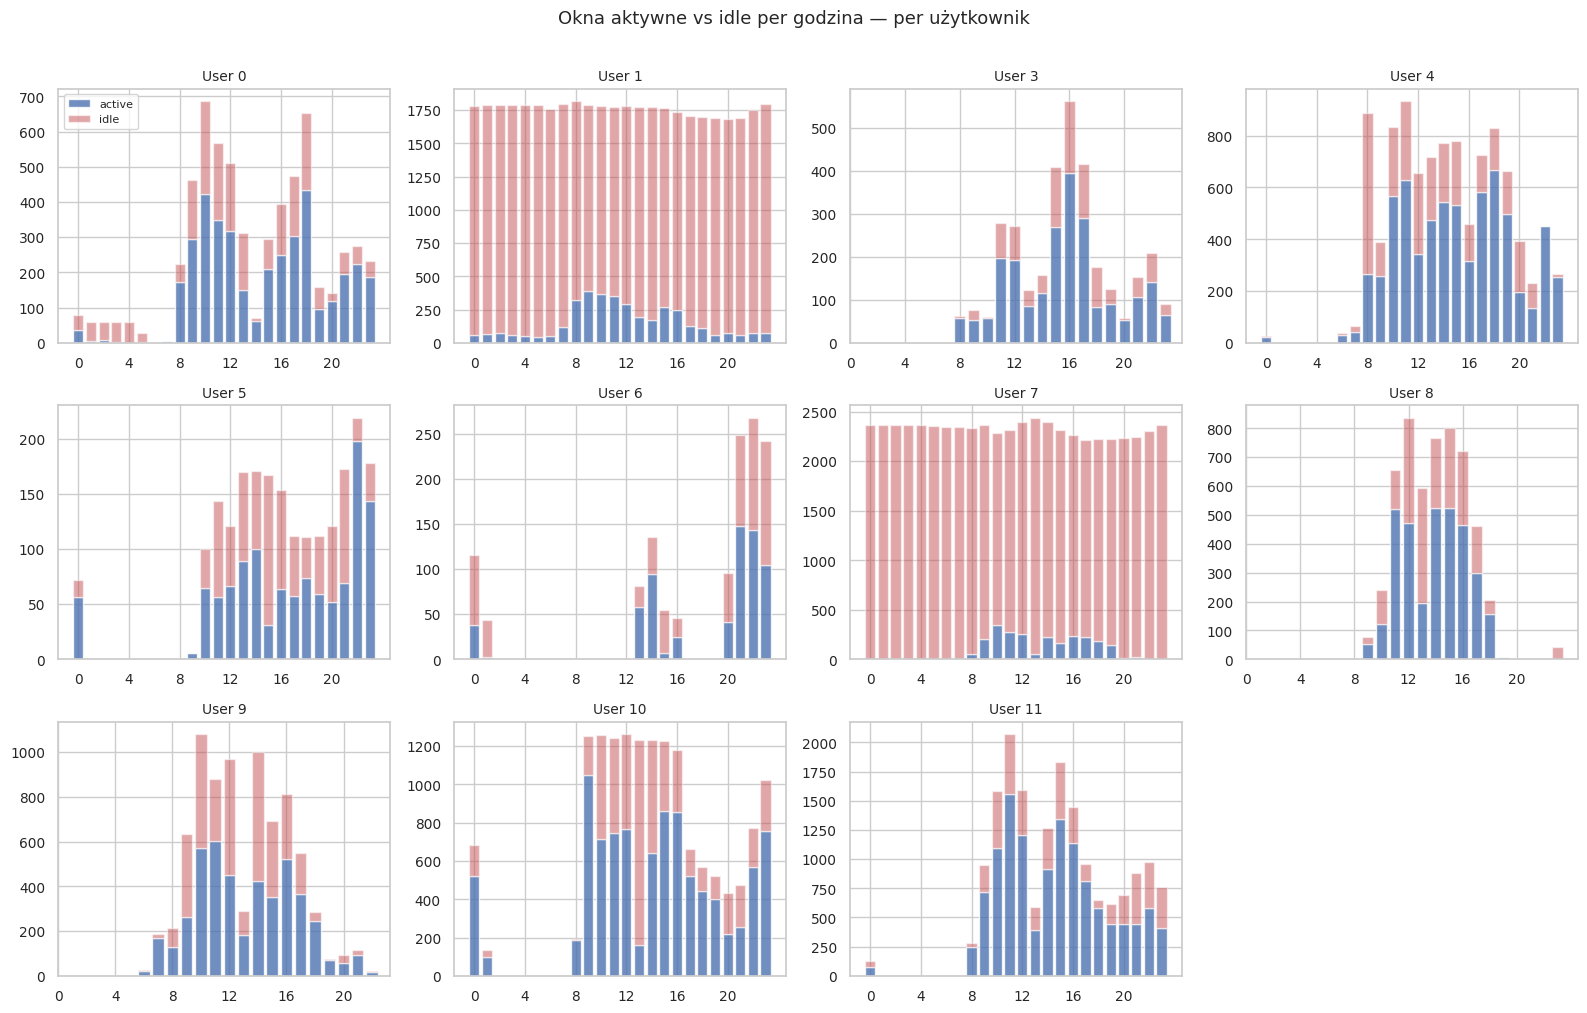

In [ ]:
# Activity by hour of day: faceted per user
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=False)
axes = axes.flatten()
users = sorted(df["USER"].unique())

for i, uid in enumerate(users):
  ax = axes[i]
  udf = df[df["USER"] == uid]
  hourly = udf.groupby("hour")["is_idle"].agg(["count", "sum"])
  hourly["active"] = hourly["count"] - hourly["sum"]
  ax.bar(hourly.index, hourly["active"], color="#4C72B0", alpha=0.8, label="active")
  ax.bar(hourly.index, hourly["sum"], bottom=hourly["active"], color="#C44E52", alpha=0.5, label="idle")
  ax.set_title(f"User {uid}", fontsize=10)
  ax.set_xlabel("")
  ax.set_xticks(range(0, 24, 4))

# Hide unused subplot
for j in range(len(users), len(axes)):
  axes[j].set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle("Okna aktywne vs idle per godzina, per użytkownik", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### Interpretacja rozkładu godzinowego

Wykres godzinowy jest użyteczny głównie jako kontrola kontekstu: użytkownicy mają różne rytmy pracy i różną ilość danych w czasie. To oznacza, że późniejsze podziały train/test powinny respektować czas i użytkowników, zamiast losowo mieszać pojedyncze minuty.

## Sekcja 5: Rozkłady kluczowych kolumn rdzeniowych

Rozkłady w oknach aktywnych (is_idle == False). Histogramy, boxploty, macierz korelacji.

Active windows: 50,909


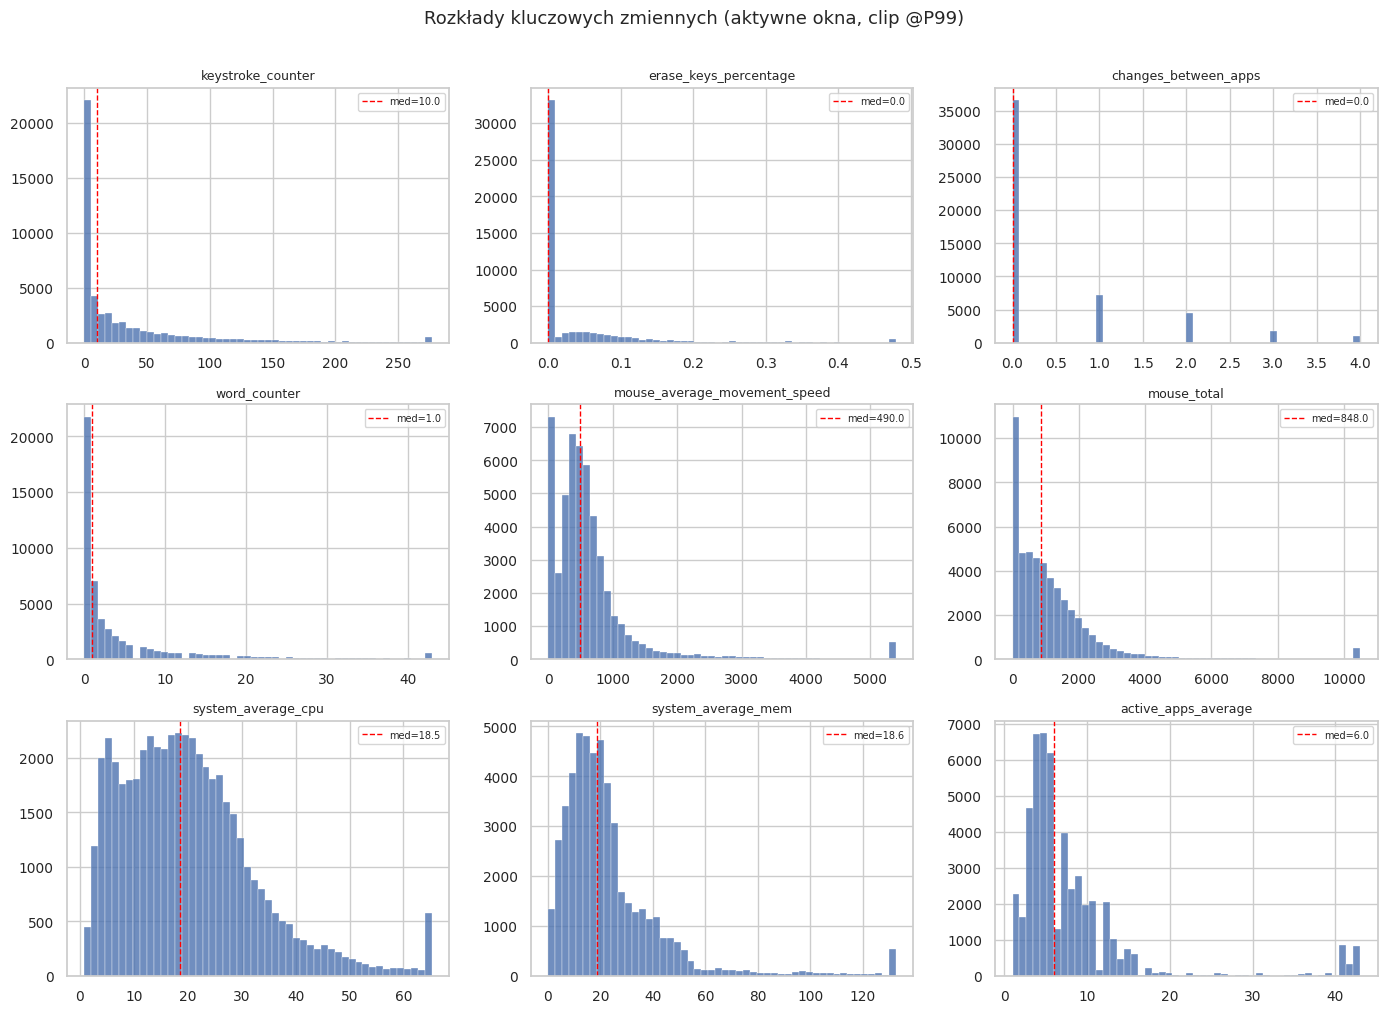

In [12]:
active = df[~df["is_idle"]].copy()
print(f"Active windows: {len(active):,}")

key_cols = [
  "keystroke_counter", "erase_keys_percentage",
  "changes_between_apps", "word_counter",
  "mouse_average_movement_speed", "mouse_total",
  "system_average_cpu", "system_average_mem",
  "active_apps_average",
]
key_cols = [c for c in key_cols if c in active.columns]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(key_cols):
  ax = axes[i // 3, i % 3]
  vals = active[col].dropna()
  # Clip at P99 for visibility
  clip_val = vals.quantile(0.99)
  vals_clipped = vals.clip(upper=clip_val)
  ax.hist(vals_clipped, bins=50, color="#4C72B0", alpha=0.8, edgecolor="white", linewidth=0.3)
  ax.set_title(col, fontsize=9)
  ax.axvline(vals.median(), color="red", linestyle="--", linewidth=1, label=f"med={vals.median():.1f}")
  ax.legend(fontsize=7)

fig.suptitle("Rozkłady kluczowych zmiennych (aktywne okna, clip @P99)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### Interpretacja rozkładów aktywnych okien

Analiza aktywnych okien ogranicza dominację idle windows i lepiej pokazuje właściwe zakresy aktywności. Przy wizualizacji konieczne jest przycięcie do P99, bo wiele cech ma ciężkie ogony.

Dla BWCI oznacza to, że komponenty powinny być odporne na skrajne wartości: przez capping, percentyle, ranking per-user albo agregację rolling-window.

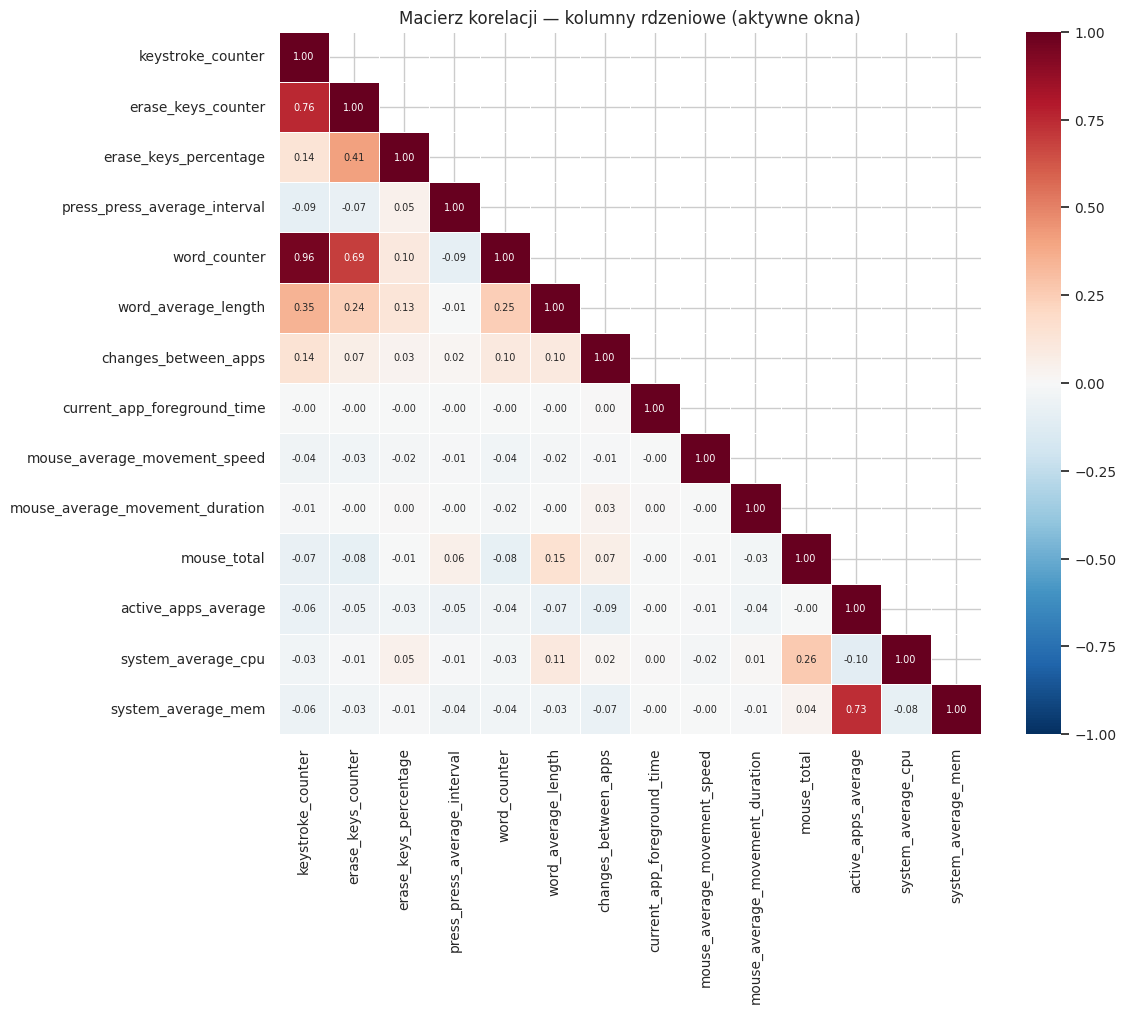

Korelacje |r| > 0.3:
  keystroke_counter <-> erase_keys_counter: +0.755
  keystroke_counter <-> word_counter: +0.955
  keystroke_counter <-> word_average_length: +0.345
  erase_keys_counter <-> erase_keys_percentage: +0.411
  erase_keys_counter <-> word_counter: +0.692
  active_apps_average <-> system_average_mem: +0.735


In [ ]:
# Correlation matrix: core numeric columns in active windows
corr_cols = [
  "keystroke_counter", "erase_keys_counter", "erase_keys_percentage",
  "press_press_average_interval", "word_counter", "word_average_length",
  "changes_between_apps", "current_app_foreground_time",
  "mouse_average_movement_speed", "mouse_average_movement_duration",
  "mouse_total", "active_apps_average",
  "system_average_cpu", "system_average_mem",
]
corr_cols = [c for c in corr_cols if c in active.columns]
corr = active[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5,
            annot_kws={"size": 7})
ax.set_title("Macierz korelacji: kolumny rdzeniowe (aktywne okna)", fontsize=12)
fig.tight_layout()
plt.show()

# Notable correlations
print("Korelacje |r| > 0.3:")
import itertools
for c1, c2 in itertools.combinations(corr_cols, 2):
  r = corr.loc[c1, c2]
  if abs(r) > 0.3:
    print(f"  {c1} <-> {c2}: {r:+.3f}")

### Interpretacja korelacji cech rdzeniowych

Korelacje są zgodne z intuicją: `keystroke_counter` silnie koreluje z `word_counter`, a `erase_keys_counter` z aktywnością pisania. To oznacza redundancję w grupie klawiaturowej.

Dla BWCI nie warto wrzucać wielu prawie równoważnych cech do osobnych komponentów. Lepiej zbudować komponenty tematyczne: interakcja, kontekst, tempo/regularność i korekty.

## Sekcja 6: Struktura aplikacji

Najpopularniejsze aplikacje, kardynalność, przełączenia kontekstu per użytkownik.

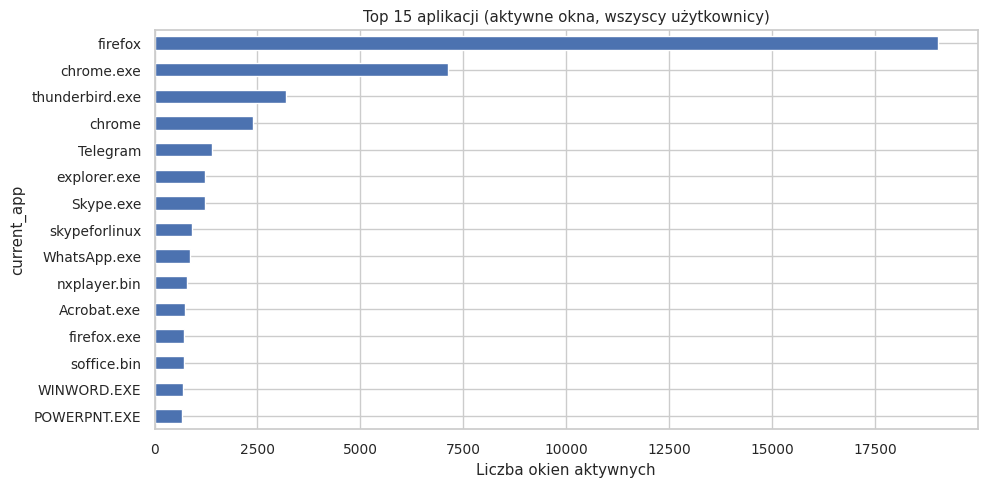


Unikalne aplikacje globalnie: 169
Unikalne penultimate_app: 179


In [14]:
# Top 15 apps globally (active windows only)
if "current_app" in active.columns:
  top_apps = active["current_app"].value_counts().head(15)
  fig, ax = plt.subplots(figsize=(10, 5))
  top_apps.plot.barh(ax=ax, color="#4C72B0")
  ax.set_xlabel("Liczba okien aktywnych")
  ax.set_title("Top 15 aplikacji (aktywne okna, wszyscy użytkownicy)")
  ax.invert_yaxis()
  fig.tight_layout()
  plt.show()

  print(f"\nUnikalne aplikacje globalnie: {active['current_app'].nunique()}")
  print(f"Unikalne penultimate_app: {active['penultimate_app'].nunique() if 'penultimate_app' in active.columns else 'N/A'}")

### Interpretacja najpopularniejszych aplikacji

Aplikacje są potencjalnie silnym sygnałem kontekstu, ale nazwy aplikacji nie powinny być bezpośrednio interpretowane jako poziom ciągłości pracy. Ta sama aplikacja może wspierać pracę albo dystrakcję zależnie od zadania.

W BWCI bezpieczniejsze są cechy strukturalne: stabilność aplikacji dominującej, liczba przełączeń i entropia aplikacji w oknie.

In [15]:
# Unique apps and context switches per user
app_stats = []
for uid in sorted(active["USER"].unique()):
  udf = active[active["USER"] == uid]
  app_stats.append({
    "user": uid,
    "unique_apps": udf["current_app"].nunique(),
    "changes_between_apps_mean": udf["changes_between_apps"].mean(),
    "changes_between_apps_median": udf["changes_between_apps"].median(),
    "changes_between_apps_max": udf["changes_between_apps"].max(),
    "top_app": udf["current_app"].value_counts().index[0],
    "top_app_pct": round(udf["current_app"].value_counts().iloc[0] / len(udf) * 100, 1),
  })

app_stats_df = pd.DataFrame(app_stats)
display(app_stats_df)

,user,unique_apps,changes_between_apps_mean,changes_between_apps_median,changes_between_apps_max,top_app,top_app_pct
0,0,35,0.4005,0.0000,6,chrome.exe,61.7000
1,1,13,0.0623,0.0000,2,firefox,77.8000
2,3,18,0.2116,0.0000,4,firefox,67.7000
3,4,32,1.0414,1.0000,8,thunderbird.exe,37.8000
4,5,19,0.4937,0.0000,6,firefox.exe,56.1000
5,6,19,0.5174,0.0000,8,chrome.exe,55.2000
6,7,20,0.4120,0.0000,4,firefox,31.8000
7,8,25,0.8214,0.0000,6,chrome.exe,63.4000
8,9,39,1.2912,1.0000,9,chrome.exe,24.3000
9,10,28,0.1801,0.0000,6,firefox,85.2000


### Interpretacja statystyk aplikacji per użytkownik

Użytkownicy różnią się liczbą aplikacji, dominującą aplikacją i intensywnością przełączeń. To sugeruje, że progi globalne dla context switching mogą być niesprawiedliwe lub niestabilne.

Dalsza konstrukcja BWCI powinna rozważyć normalizację per-user albo analizę wrażliwości na wariant globalny vs personalizowany.

/tmp/ipykernel_1864890/2149154558.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=[str(u) for u in sorted(active["USER"].unique())],


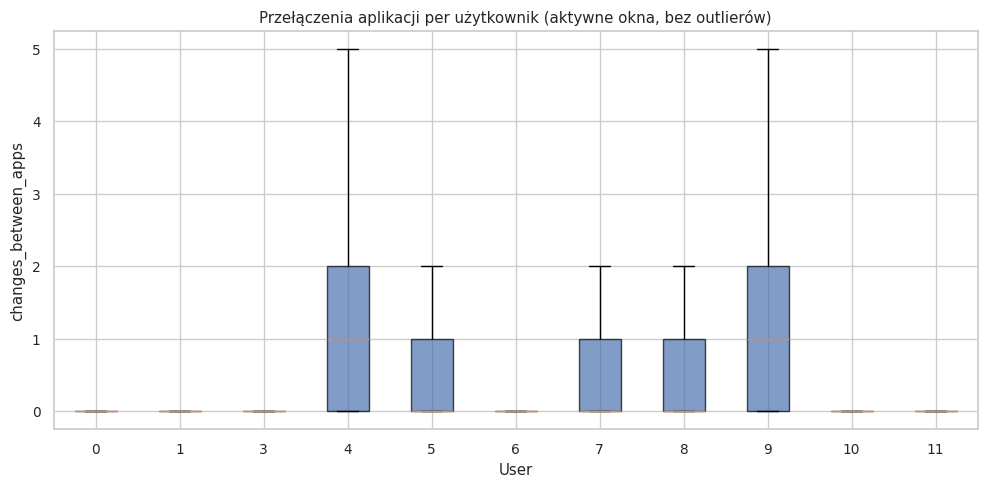

In [ ]:
# changes_between_apps distribution per user: faceted boxplot
fig, ax = plt.subplots(figsize=(10, 5))
data_for_box = [active.loc[active["USER"] == uid, "changes_between_apps"].dropna().values
                for uid in sorted(active["USER"].unique())]
bp = ax.boxplot(data_for_box, labels=[str(u) for u in sorted(active["USER"].unique())],
                patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
  patch.set_facecolor("#4C72B0")
  patch.set_alpha(0.7)
ax.set_xlabel("User")
ax.set_ylabel("changes_between_apps")
ax.set_title("Przełączenia aplikacji per użytkownik (aktywne okna, bez outlierów)")
fig.tight_layout()
plt.show()

### Interpretacja przełączeń aplikacji

Rozkład `changes_between_apps` pokazuje, że dla większości użytkowników mediana jest niska, ale część użytkowników ma wyraźnie wyższą zmienność kontekstu. Nie należy zakładać, że każde przełączenie oznacza przerwanie pracy.

Dla BWCI ta cecha powinna działać jako sygnał niestabilności kontekstu dopiero w połączeniu z oknem czasowym i innymi cechami, nie jako samodzielna etykieta rozproszenia.

## Sekcja 7: Podsumowanie i decyzje

### Kluczowe wnioski

1. **Rozmiar danych**: 166 879 wierszy (1-minutowych okien) od 11 użytkowników po wykluczeniu User2.
2. **Proporcja idle/active**: ~69.5% okien jest idle. To znaczy, że metryki aktywności trzeba analizować warunkowo, a nie tylko globalnie.
3. **Jawnych braków (`NaN`) nie stwierdzono**. Nie ma więc podstaw do analizy korelacji jawnych nulli z `is_idle`.
4. **Semantyczne zera występują w metrykach czasowych**. Nie należy ich automatycznie imputować; trzeba je traktować jako sygnał zależny od kontekstu aktywności lub dodać flagi jakości.
5. **IQR na danych zero-inflated jest tylko diagnostyką przesiewową**. Dla cech z medianą równą 0 dodatnie wartości często są normalną aktywnością, nie anomalią.
6. **Realne problemy jakościowe**:
   - `click_speed_average_0`: ekstremalne wartości timestamp-like; wymaga cappingu albo wyłączenia z pierwszej wersji BWCI.
   - `current_app_foreground_time`: wartości >60s w 1-minutowym oknie; wymaga cappingu do 60s albo flagi jakości.
   - `active_apps_average` i metryki systemowe mogą zawierać szum procesowy, więc nie powinny być rdzeniem BWCI bez dalszej walidacji.
7. **Profile użytkowników są silnie zróżnicowane**. User1 i User7 mają bardzo niski udział aktywnych okien, więc walidacja per-user i leave-one-user-out są obowiązkowe.

### Decyzje dla następnego notebooka

- BWCI powinien być liczony na rolling windows i uwzględniać `idle_ratio`, zamiast interpretować pojedyncze minuty bez kontekstu.
- Cechy klawiatury i myszy powinny być liczone warunkowo na aktywnych oknach albo agregowane w oknach czasowych.
- `current_app_foreground_time` należy przyciąć do 60s lub oznaczyć flagą jakości przed użyciem.
- `click_speed_average_0` nie powinien wejść do pierwszej wersji BWCI bez cappingu i analizy wrażliwości.
- Zmienność między użytkownikami powinna zostać zachowana w analizie; nie należy opierać wniosków wyłącznie na agregacie globalnym.

### Kandydaci do konstrukcji BWCI

- **Ciągłość interakcji**: `is_idle`, `keystroke_counter`, `mouse_total` agregowane w rolling windows.
- **Stabilność kontekstu**: `changes_between_apps`, udział aplikacji dominującej, entropia aplikacji w oknie.
- **Dynamika wejścia**: `press_press_average_interval`, `press_press_stddev_interval`, `erase_keys_percentage`, po warunkowym czyszczeniu.
- **Cechy pomocnicze**: `system_average_cpu`, `system_average_mem`, `active_apps_average`, tylko jako kandydaci do sprawdzenia, nie jako rdzeń indeksu.

### Następny krok

Następny notebook powinien zająć się konstrukcją BWCI, ale musi wykorzystać powyższe decyzje: najpierw czyszczenie/flagowanie problematycznych wartości, potem rolling-window features, a dopiero później definicja komponentów i etykiet pogorszenia ciągłości pracy.
